# Progetto finale: Titanic - Laboratorio di Python
*Lazzarotto Francesco, Rolando Francesco*

___

### Import delle librerie e lettura dei dati
Prima di inziare, importiamo le librerie `pandas` e `matplotlib` per l'analisi dei dati e per i grafici.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Successivamente, leggiamo i dati dal file ".csv".

In [3]:
def carica_dati(file_csv):
    try:
        titanic_dati = pd.read_csv(file_csv)
        return titanic_dati
    except FileNotFoundError:
        print("File non trovato.")
        return None
    except Exception as e:
        print(f"Errore durante il caricamento dei dati: {str(e)}")
        return None
    
dati = carica_dati("dataset/titanic_survivors.csv")

Prima di iniziare con gli esercizi, testiamo che la lettura funzioni estraendo le prime cinque righe dal dataset.


___

In [5]:
display(dati.head())

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


### Esercizio 1
*Esamina la distribuzione delle età dei passeggeri del Titanic. Puoi creare un istogramma delle età per vedere quali fasce di età sono più rappresentate tra i passeggeri.*

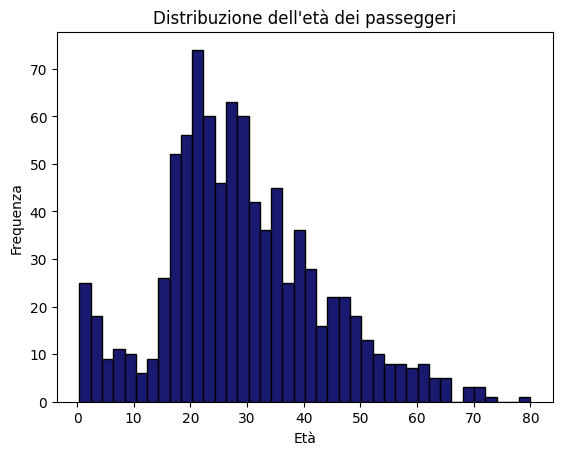

In [4]:
# creiamo l'istogramma
plt.hist(dati['Age'], bins=40, color='midnightblue', edgecolor='black')

# titolo
plt.title("Distribuzione dell'età dei passeggeri")

# etichette degli assi
plt.xlabel('Età')
plt.ylabel('Frequenza')

# stampiamo l'istogramma
plt.show()


**Commento:**

La distribuzione rispecchia le aspettative che si possono avere per una variabile come l'età: la fascia 20-40 anni è quella dove si collocano la maggior parte delle frequenze, mentre agli estremi c'è un calo significativo del numero. Quello che è interessante notare è che c'è un discreto quantitativo di persone anche nelle fasce d'età più ridotte.

___

### Esercizio 2
*Fra i sopravvissuti, calcolare quanti fossero in prima, seconda e terza classe in Percentuale (“Fra i sopravvissuti, il X% era di prima classe...”).*

Sopravvissuti suddivisi per classe:
Il 39.77% dei sopravvissuti appartiene alla 1 classe.
Il 34.80% dei sopravvissuti appartiene alla 3 classe.
Il 25.44% dei sopravvissuti appartiene alla 2 classe.


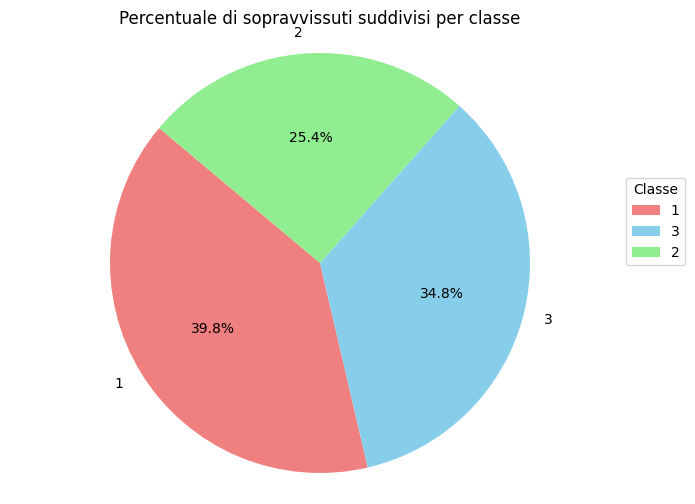

In [5]:
# otteniamo solo i sopravvissuti (==1)
sopravvissuti = dati[dati['Survived'] == 1]

# calcoliamo il conteggio dei sopravvissuti per ciascuna classe
conteggio_sopravvissuti_per_classe = sopravvissuti['Pclass'].value_counts()

# uniamo tutto e ottenia,o il totale dei sopravvissuti
totale_sopravvissuti = sopravvissuti.shape[0]

# calcoliamo la percentuale di sopravvissuti per ciascuna classe rispetto al totale dei sopravvissuti
percentuali_per_classe = (conteggio_sopravvissuti_per_classe / totale_sopravvissuti) * 100

# stampiamo i risultati
print("Sopravvissuti suddivisi per classe:")
for classe, percentuale in percentuali_per_classe.items():
    print(f"Il {percentuale:.2f}% dei sopravvissuti appartiene alla {classe} classe.")
    
# creazione e stampa del grafico a torta
plt.figure(figsize=(8, 6))
plt.pie(percentuali_per_classe, labels=percentuali_per_classe.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'skyblue', 'lightgreen'])
plt.axis('equal')
plt.title('Percentuale di sopravvissuti suddivisi per classe')
plt.legend(title="Classe", loc="upper right", fontsize=10, bbox_to_anchor=(1.1, 0.7))
plt.show()

___

### Esercizio 3
*Calcolare qual è la percentuale di sopravvissuti in ciascuna classe. (“Il Y% dei passeggeri di prima classe è sopravvissuto”)*

Percentuale di sopravvissuti in ciascuna classe:
Dei passeggeri di 1a classe è sopravvissuto il 62.96%.
Dei passeggeri di 2a classe è sopravvissuto il 47.28%.
Dei passeggeri di 3a classe è sopravvissuto il 24.44%.


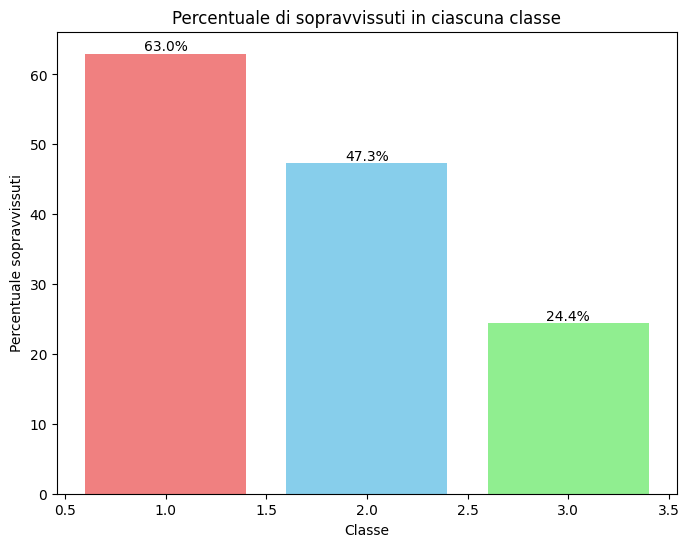

In [6]:
# raggruppiamo i dati per classe di passeggeri
# manteniamo solamente i sopravvissuti
# moltiplichiamo per 100 per ottenere i valori percentuali
conteggio_sopravvissuti = dati.groupby('Pclass')['Survived'].mean() * 100

# stampiamo i risultati
print("Percentuale di sopravvissuti in ciascuna classe:")
for classe, percentuale in conteggio_sopravvissuti.items():
    print(f"Dei passeggeri di {classe}a classe è sopravvissuto il {percentuale:.2f}%.")
    
# creiamo e stampiamo il  grafico a barre
plt.figure(figsize=(8, 6))
bars = plt.bar(conteggio_sopravvissuti.index, conteggio_sopravvissuti, color=['lightcoral', 'skyblue', 'lightgreen'])
for bar in bars:
    valori_percentuali = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, valori_percentuali, f'{valori_percentuali:.1f}%', ha='center', va='bottom')
plt.title('Percentuale di sopravvissuti in ciascuna classe')
plt.xlabel('Classe')
plt.ylabel('Percentuale sopravvissuti')
plt.xticks(rotation=0)
plt.show()
    

___

### Distinzione per sesso (da non includere!!!)

Percentuale di sopravvissuti per oguno dei due sessi:
Fra i passeggeri di sesso femminile è sopravvissuto il 74.20%.
Fra i passeggeri di sesso maschile è sopravvissuto il 19.02%.


Sopravvissuti suddivisi per sesso:
Percentuale di sopravvissuti maschi: 31.87%
Percentuale di sopravvissute femmine: 68.13%




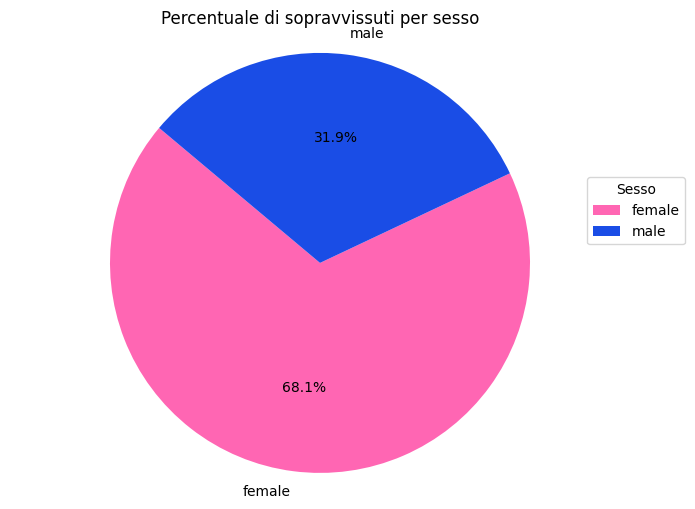

In [7]:
# PRIMA PARTE --------------------------------------------------------------
# raggruppiamo i passeggeri per sesso
# manteniamo solamente i sopravvissuti
# moltiplichiamo per 100 per ottenere i valori percentuali
conteggio_sopravvissuti = dati.groupby('Sex')['Survived'].mean() * 100

# stampiamo i risultati
print("Percentuale di sopravvissuti per oguno dei due sessi:")
dizionario_sesso = {"male":"maschile", "female":"femminile"}
for sesso, percentuale in conteggio_sopravvissuti.items():
    print(f"Fra i passeggeri di sesso {dizionario_sesso[sesso]} è sopravvissuto il {percentuale:.2f}%.")
print("\n")


# SECONDA PARTE -------------------------------------------------------------- 
# filtriamo il DataFrame per includere solo i sopravvissuti
sopravvissuti = dati[dati['Survived'] == 1]

# contiamo il numero di sopravvissuti per ciascun sesso
conteggio_sopravvissuti_per_sesso = sopravvissuti['Sex'].value_counts()

# calcoliamo la percentuale di sopravvissuti maschi e femmine rispetto al totale dei sopravvissuti
percentuale_maschi = (conteggio_sopravvissuti_per_sesso['male'] / sopravvissuti.shape[0]) * 100
percentuale_femmine = (conteggio_sopravvissuti_per_sesso['female'] / sopravvissuti.shape[0]) * 100

#stampiamo i risultati
print("Sopravvissuti suddivisi per sesso:")
print(f"Percentuale di sopravvissuti maschi: {percentuale_maschi:.2f}%")
print(f"Percentuale di sopravvissute femmine: {percentuale_femmine:.2f}%")
print("\n")


# TERZA PARTE --------------------------------------------------------------
# creazione del grafico a torta
colors =[(1, 0.4, 0.7), (0.1, 0.3, 0.9)]
plt.figure(figsize=(8, 6))
plt.pie(conteggio_sopravvissuti_per_sesso, labels=conteggio_sopravvissuti_per_sesso.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.axis('equal')
plt.title('Percentuale di sopravvissuti per sesso')
plt.legend(title="Sesso", loc="upper right", fontsize=10, bbox_to_anchor=(1.1, 0.7))

# Mostra il grafico a torta
plt.show()

___

### Esercizio 4
*Ci sono differenze nel numero di sopravvissuti fra uomini e donne, per classe?*

Numero di sopravvissuti per classe e sesso:


Sex,female,male
Pclass,,
1,91,45
2,70,17
3,72,47




Percentuali di sopravvissuti per classe e sesso:


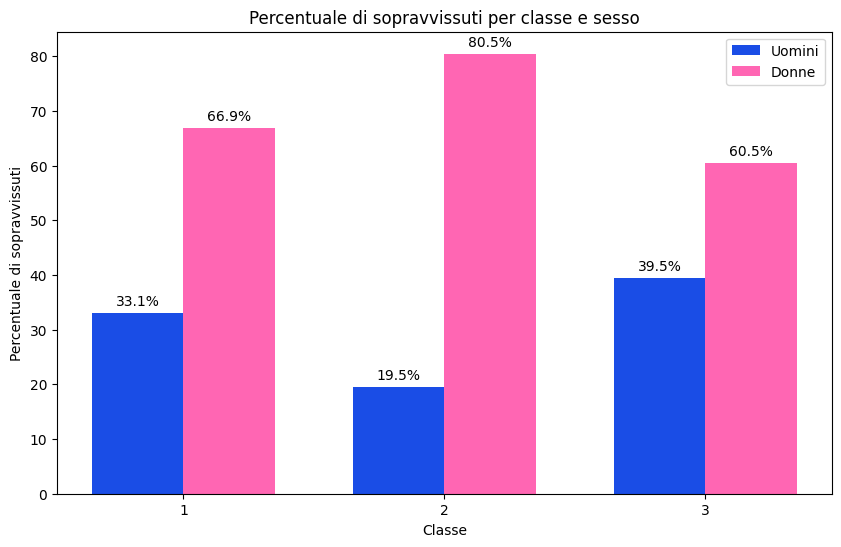

In [8]:
# valori numerici dei sopravvissuti per sesso e per classe
conteggio_sopravvissuti = dati[dati['Survived'] == 1].groupby(['Pclass', 'Sex']).size().unstack()

# stampa dei valori numerici in tabella
print("Numero di sopravvissuti per classe e sesso:")
display(conteggio_sopravvissuti)

# valori percentuali
percentuali_sopravvissuti = conteggio_sopravvissuti.div(conteggio_sopravvissuti.sum(axis=1), axis=0) * 100

# creiamo il grafico a barre raggruppato con le percentuali
labels = percentuali_sopravvissuti.index
percentuale_uomini = percentuali_sopravvissuti['male']
percentuale_donne = percentuali_sopravvissuti['female']

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x, percentuale_uomini, width, label='Uomini', color=(0.1, 0.3, 0.9))
bars2 = ax.bar([i + width for i in x], percentuale_donne, width, label='Donne', color=(1, 0.4, 0.7))

# impostiamo le etichette, il titolo e la leggenda
ax.set_xlabel('Classe')
ax.set_ylabel('Percentuale di sopravvissuti')
ax.set_title('Percentuale di sopravvissuti per classe e sesso')
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(labels)
ax.legend()

# aggiungiamo i valori percentuali in cima alle barre
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{:.1f}%'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
autolabel(bars1)
autolabel(bars2)

# stampa del grafico
print("\n")
print("Percentuali di sopravvissuti per classe e sesso:")
plt.show()


**Commento:**

Quello che emerge, innanzitutto, è la differenza a livello numerico fra i passeggeri sopravvissuti nella prima classe (136), rispetto alla prima (119) e alla seconda classe (89). <br>
Questi numeri diventano rilevanti soprattutto osservando il numero totale dei passeggeri appartenenti a ciascuna classe (tabella riportata di seguito): la prima classe, che aveva il minor numero di passeggeri (216) è anche quella ad aver il maggior numero dei sopravvissuti (136).

A livello di differenze fra i sessi, il gap maggiore è nella seconda classe: le femmine sono l'80%, mentre i maschi solamente il 20%. <br>
Infine, per la prima classe la differenza percentuale è del 33,8%, mentre per la teza è del 21%, sempre a favore delle femmine.

In [9]:
# tabella con i passeggeri per ogni classe
conteggio_passeggeri_per_classe = dati['Pclass'].value_counts().sort_index()

percentuali_passeggeri_per_classe = (conteggio_passeggeri_per_classe / dati.shape[0]) * 100

tabella_percentuali = pd.DataFrame({
    'Numero totale di passeggeri': conteggio_passeggeri_per_classe,
    'Percentuale di passeggeri': percentuali_passeggeri_per_classe
})

print("Passeggeri per ogni classe:")
display(tabella_percentuali)

Passeggeri per ogni classe:


,Numero totale di passeggeri,Percentuale di passeggeri
Pclass,,
1,216,24.351747
2,184,20.744081
3,487,54.904171


___

### Esercizio 5
1. *In quale classe si è rilevata una percentuale di sopravvivenza maggiore per gli uomini?*

2. *Ci sono differenze fra quelli con coniuge a bordo e quelli senza?*

**Punto n.1:**

In [15]:
# raggruppiamo i dati per classe
# filtriamo ottenendo solo gli uomini
# calcoliamo la media dei sopravvissuti per ogni classe
conteggio_sopravvissuti_uomini = dati[dati['Sex'] == 'male'].groupby('Pclass')['Survived'].mean()

# otteniamo l'indice della classe con la percentuale più alta
classe_maggiore_sopravvivenza_uomini = conteggio_sopravvissuti_uomini.idxmax()

# stampa del risultato
print(f"La classe con la maggiore percentuale di sopravvivenza per gli uomini è la {classe_maggiore_sopravvivenza_uomini}a.")



La classe con la maggiore percentuale di sopravvivenza per gli uomini è la 1a.


**Punto n.2:**

Passeggeri sopravvissuti (con coniuge a bordo):
Pclass
1    74.683544
2    57.812500
3    25.714286
Name: Survived, dtype: float64

Passeggeri sopravvissuti (senza coniuge a bordo):
Pclass
1    56.204380
2    41.666667
3    23.919308
Name: Survived, dtype: float64

Rappresentazione grafica:


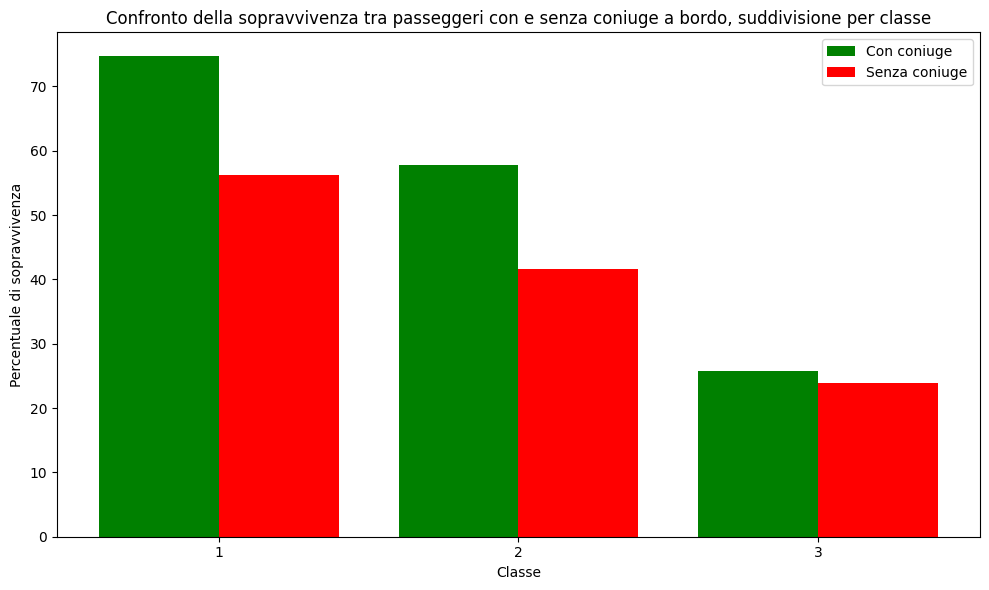

In [25]:
# #raggruppiamo per classe
# filtriamo per ottenere i passeggeri con cogniuge a bordo (campo "Siblings/Spouses Aborard" > 0)
# calcoliamo la percentuale dei sopravvissuti
conteggio_sopravvissuti_con_coniuge = dati[dati['Siblings/Spouses Aboard'] > 0].groupby('Pclass')['Survived'].mean() * 100

# #raggruppiamo per classe
# filtriamo per ottenere i passeggeri senza cogniuge a bordo (campo "Siblings/Spouses Aborard" == 0)
# calcoliamo la percentuale dei sopravvissuti
conteggio_sopravvissuti_senza_coniuge = dati[dati['Siblings/Spouses Aboard'] == 0].groupby('Pclass')['Survived'].mean() * 100

# risultati
print("Passeggeri sopravvissuti (con coniuge a bordo):")
print(conteggio_sopravvissuti_con_coniuge)
print("\nPasseggeri sopravvissuti (senza coniuge a bordo):")
print(conteggio_sopravvissuti_senza_coniuge)

# rappresentazione con grafico
plt.figure(figsize=(10, 6))
# con coniuge a bordo
plt.bar(conteggio_sopravvissuti_con_coniuge.index - 0.2, conteggio_sopravvissuti_con_coniuge, width=0.4, label='Con coniuge', color='green')
# senza coniuge a bordo
plt.bar(conteggio_sopravvissuti_senza_coniuge.index + 0.2, conteggio_sopravvissuti_senza_coniuge, width=0.4, label='Senza coniuge', color='red')
# etichette e titolo
plt.xlabel('Classe')
plt.ylabel('Percentuale di sopravvivenza')
plt.title('Confronto della sopravvivenza tra passeggeri con e senza coniuge a bordo, suddivisione per classe')
plt.xticks(conteggio_sopravvissuti_con_coniuge.index, ['1', '2', '3'])
plt.legend()

# stampa del grafico
print ("\nRappresentazione grafica:")
plt.tight_layout()
plt.show()

    
    

**Commento:**

Come possiamo osservare dal grafico, per ciascuna delle classi è maggiore la percentuale di sopravvissuti per i passeggeri che avevano un coniuge a bordo.

___

### Esercizio 6
*Analizza la distribuzione del costo dei biglietti per classe. Confronta il prezzo medio, minimo e massimo.*

In [12]:
# raggruppiamo i dati in base alla classe dei passeggeri e seleziona la colonna dei costi dei biglietti
gruppo_per_classe = dati.groupby('Pclass')['Fare']

statistiche_costo = gruppo_per_classe.describe()

display(statistiche_costo)

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,487.0,13.707707,11.817309,0.0,7.75000,8.0500,15.5,69.5500


**Commento:**


Osservando la tabella ripostata sopra, possiamo trarre le seguenti conclusioni (si suppone un prezzo in dollari "$"):

1. Classe 1: Il costo medio del biglietto è il più alto tra le classi, con un valore di 84.15 \$\. Il costo minimo del biglietto è 0.0 \$\, il che potrebbe indicare alcuni errori nei dati o situazioni particolari come passaggi per l'equipaggio. Il costo massimo del biglietto è molto elevato, con un valore di 512.33 \$\.

2. Classe 2: Il costo medio del biglietto è significativamente inferiore rispetto alla classe 1, con un valore di 20.66 \$\. Il costo minimo del biglietto è ancora 0.0, ma il costo massimo è molto più basso rispetto alla classe 1, con un valore di 73.50 \$\. I biglietti sono quindi più accessibili rispetto alla prima classe.

3. Classe 3: La classe 3 ha il costo medio del biglietto più basso tra tutte le classi, con un valore di 13.71 \$\. Il costo minimo del biglietto è ancora 0.0 \$\, e il costo massimo è 69.55 \$\, il che indica che anche nella classe 3 ci sono passeggeri che hanno pagato un prezzo relativamente elevato per il biglietto, sebbene inferiore rispetto alle classi superiori.

In generale, possiamo osservare una chiara differenza nei costi dei biglietti tra le diverse classi, con la classe 1 che ha i costi più elevati e la classe 3 che ha i costi più bassi.

___